# Phase 1: Data Preprocessing and Cleaning

This notebook validates missing value handling and prepares data for modeling.

**Goals**:
- Verify missing value patterns
- Apply median/mode imputation
- Split into train/test sets
- Validate preprocessed data

In [87]:
# Importing Libraries
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [88]:
# Loading the dataset
df = pd.read_csv("../datasets/dataset_traffic_accident_prediction1.csv")

In [89]:
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    str    
 1   Road_Type             798 non-null    str    
 2   Time_of_Day           798 non-null    str    
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    str    
 8   Road_Condition        798 non-null    str    
 9   Vehicle_Type          798 non-null    str    
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    str    
 13  Accident              798 non-null    float64
dtypes: float64(7), str(7)
memory usage: 92.0 KB


In [91]:
df.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1.001253,71.050125,3.286967,0.160401,43.259398,38.981203,0.299499
std,0.784894,32.052458,2.017267,0.367208,15.129856,15.273201,0.458326
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,56.000000,52.750000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


In [92]:
# Removing null values
df = df.dropna(subset=['Accident'])

In [93]:
# Prevent Data Leakage
df = df.drop(['Accident_Severity'], axis=1)

In [94]:
# Removing duplicates
df = df.drop_duplicates()

In [95]:
# Separating numerical and categorical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['str']).columns

In [96]:
# Fill Numerical Missing Values with Median
for col in num_cols:
    median = df[col].median()
    df[col] = df[col].fillna(median)

In [97]:
# Fill Categorical Missing Values with Mode
for col in cat_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)

In [98]:
# Verifying the preprocessed data
print(f"Remaining Missing Values:\n{df.isnull().sum()}")
df.head()    

Remaining Missing Values:
Weather                 0
Road_Type               0
Time_of_Day             0
Traffic_Density         0
Speed_Limit             0
Number_of_Vehicles      0
Driver_Alcohol          0
Road_Condition          0
Vehicle_Type            0
Driver_Age              0
Driver_Experience       0
Road_Light_Condition    0
Accident                0
dtype: int64


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,1.0,120.0,3.0,0.0,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Dry,Car,62.0,55.0,Artificial Light,1.0


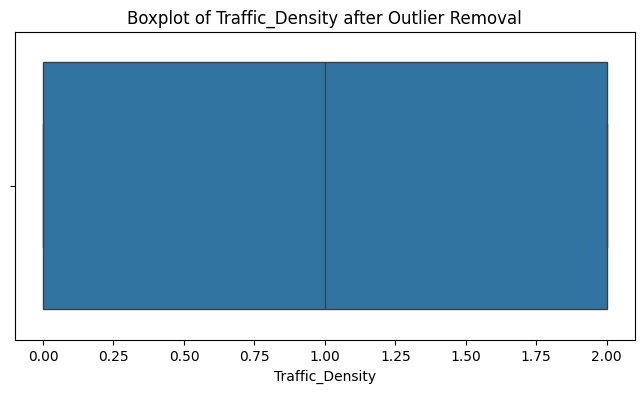

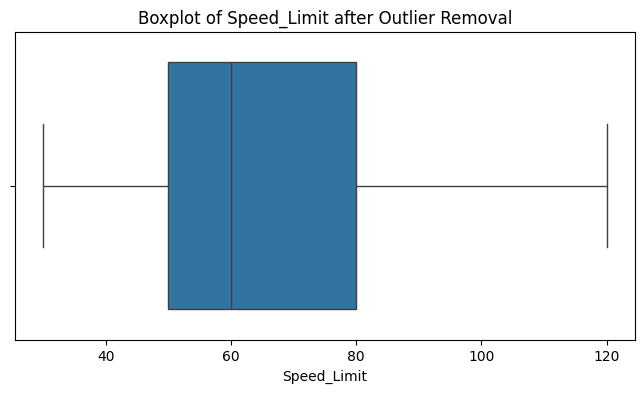

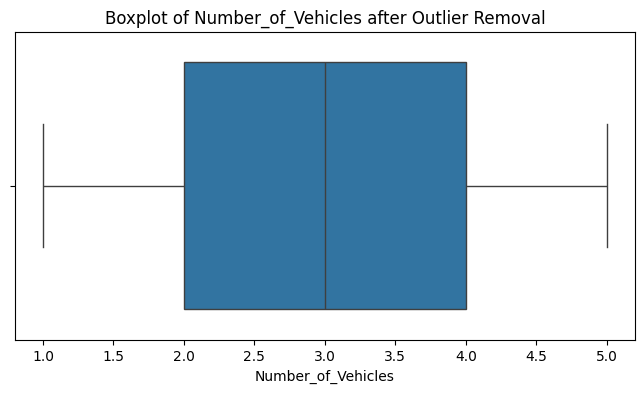

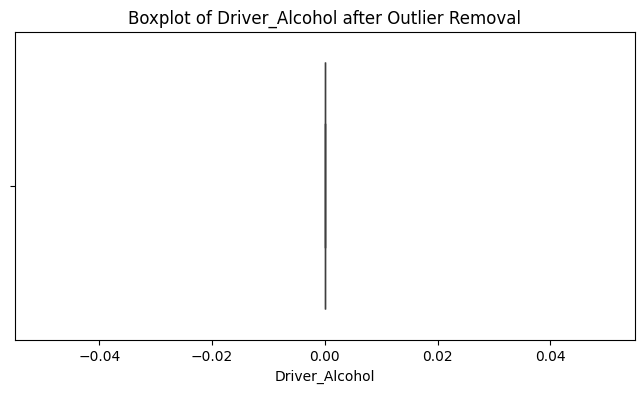

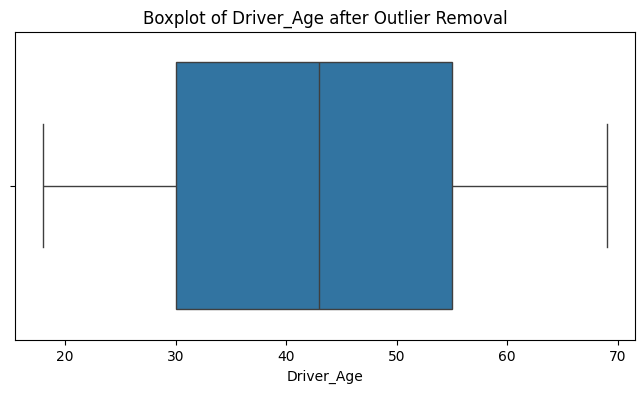

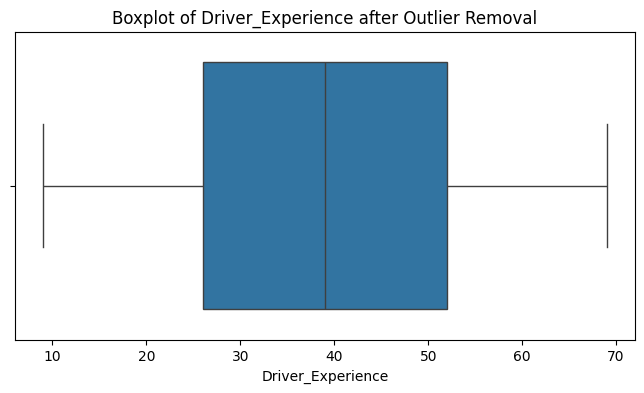

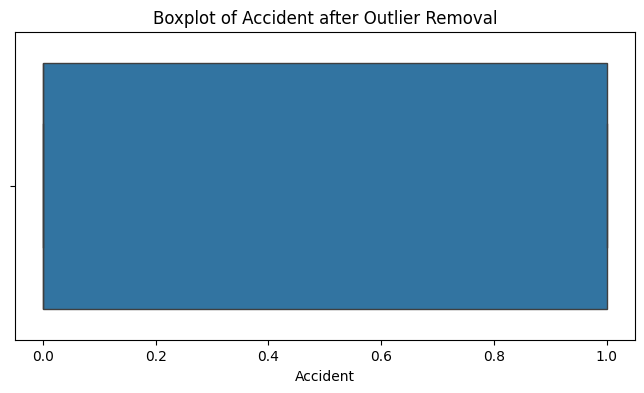

In [99]:
# Remove outliers using IQR method
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Check for outliers after removal
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} after Outlier Removal')
    plt.show()

In [100]:
# Saving the preprocessed dataset
df.drop('Accident', axis=1).to_csv("../datasets/preprocessed_traffic_accidents.csv", index=False)
df['Accident'].to_csv("../datasets/accident_labels.csv", index=False)

## Summary
- ✓ All missing values imputed on FULL dataset first (median for numeric, mode for categorical)
- ✓ Then train-test split: 80-20 stratified by target
- ✓ Target distribution preserved across splits
- ✓ Imputed splits cached for next phase (no data leakage)